In [1]:
import xarray as xr
import numpy as np
from scipy.fft import fft2, ifft2, fftfreq
import matplotlib.pyplot as plt

/home/incois/sridevi/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
hs=xr.open_dataset('pCO2_Ensemble_Clim_HIS.nc')
ROMS = hs.sel(
    LON_RHO=slice(78,100),
    LAT_RHO=slice(5,25),
    )
print(ROMS)

<xarray.Dataset> Size: 6MB
Dimensions:  (LAT_RHO: 250, LON_RHO: 265, month: 12)
Coordinates:
  * LAT_RHO  (LAT_RHO) float32 1kB 5.015 5.098 5.181 5.264 ... 24.8 24.87 24.95
  * LON_RHO  (LON_RHO) float32 1kB 78.0 78.08 78.17 78.25 ... 99.83 99.92 100.0
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    pCO2     (month, LAT_RHO, LON_RHO) float64 6MB ...


In [3]:
import xarray as xr
import numpy as np
from scipy.ndimage import gaussian_filter


def gaussian_scale_variance(flux, grid_resolution, cutoff_deg):
    """
    Gaussian scale decomposition for air-sea CO2 flux

    Parameters
    ----------
    flux : xarray.DataArray
        Input field with dimensions (time, lats, lons)

    cutoff_deg : float
        Physical cutoff scale in degrees
        Examples:
            4.0  -> mesoscale large-scale separation
            1.0  -> fine-scale
            0.25 -> very fine-scale

    Returns
    -------
    large_all : xarray.DataArray
        Gaussian filtered large-scale field

    residual : xarray.DataArray
        Small-scale residual field

    total_variance : xarray.DataArray
        Total variance

    large_variance : xarray.DataArray
        Variance of filtered field

    guo_variance : xarray.DataArray
        Guo-style small-scale variance
    """

    # -----------------------------
    # Remove temporal mean
    # -----------------------------
#     flux_anom = flux - flux.mean(dim='month')
    time_dim = 'month' if 'month' in flux.dims else 'time'
    flux_anom = flux - flux.mean(dim=time_dim)

#     month: 12, LAT_RHO379_689: 243, LON_RHO577_841: 265)
    # -----------------------------
    # Grid resolution
    # -----------------------------
    deg_res = grid_resolution

    # -----------------------------
    # Convert cutoff to sigma
    # -----------------------------
    sigma_deg = cutoff_deg / np.sqrt(12)
    sigma = sigma_deg / deg_res

    print(f"Cutoff = {cutoff_deg}°")
    print(f"Sigma = {sigma:.2f} grid cells")

    # -----------------------------
    # Filtering loop
    # -----------------------------
    large_list = []

    for t in range(flux.month.size):

        field = flux_anom.isel(month=t)

        mask = np.isnan(field)

        field_filled = field.fillna(0)

        weights = (~mask).astype(float)

        smooth_num = gaussian_filter(field_filled, sigma=sigma)
        smooth_den = gaussian_filter(weights, sigma=sigma)

        large = smooth_num / smooth_den

        # Detect coordinate names automatically
        lat_name = [d for d in flux.dims if 'LAT' in d or 'lat' in d][0]
        lon_name = [d for d in flux.dims if 'LON' in d or 'lon' in d][0]

#         if 'lats' in flux.dims:
#             lat_name = 'lats'
#             lon_name = 'lons'
#         else:
#             lat_name = 'lat'
#             lon_name = 'lon'
        
        large = xr.DataArray(
            large,
            dims=(lat_name, lon_name),
            coords={
                lat_name: flux[lat_name],
                lon_name: flux[lon_name]
            }
        )

        large = large.where(~mask)

        large_list.append(large)

    # -----------------------------
    # Combine
    # -----------------------------
    large_all = xr.concat(large_list, dim='month')
    large_all['month'] = flux.month

    # -----------------------------
    # Residual field
    # -----------------------------
    residual = flux_anom - large_all

    # -----------------------------
    # Variance
    # -----------------------------
    total_variance = (flux_anom ** 2).mean(dim='month')

    large_variance = (large_all ** 2).mean(dim='month')

    guo_variance = total_variance - large_variance

    return large_all, residual, total_variance, large_variance, guo_variance

In [4]:
eddy_ROMS = gaussian_scale_variance(ROMS['pCO2'],grid_resolution=1/12,cutoff_deg=2)
# eddy_ROMS

Cutoff = 2°
Sigma = 6.93 grid cells


/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_num / smooth_den
/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_num / smooth_den
/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_num / smooth_den
/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_num / smooth_den
/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_num / smooth_den
/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_num / smooth_den
/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_num / smooth_den
/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_n

In [5]:
### needs to update data files here for Future Downscaled influence to understand  .sel(LON_RHO=slice(30,119.5),LAT_RHO=slice(-31,31)) 
CMIP_GF = xr.open_dataset('CMIP_GFDL_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
CMIP_CN1 = xr.open_dataset('CMIP_CNRM_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
CMIP_UK1 = xr.open_dataset('CMIP_UKESM_pCO2_final_upto_2100.nc').pCO2.sel(LON_RHO=slice(78,100),LAT_RHO=slice(4.5,25))
# CMIP_GF,CMIP_CN,CMIP_UK,  

In [6]:
# # model have low resolution that obserrvations so, observations need to regrid
CMIP_UK = []
CMIP_UK = CMIP_UK1.interp(
    LON_RHO=CMIP_GF.LON_RHO,
    LAT_RHO=CMIP_GF.LAT_RHO,
    method='nearest'
)
CMIP_CN = []
CMIP_CN = CMIP_CN1.interp(
    LON_RHO=CMIP_GF.LON_RHO,
    LAT_RHO=CMIP_GF.LAT_RHO,
    method='nearest'
)

In [7]:
CMIP_CN['TIME'] = xr.cftime_range(
    start=str(CMIP_CN.TIME.values[0])[:10],
    periods=len(CMIP_CN.TIME),
    freq="MS"
)
# print(CMIP_CN.coords)
CMIP_CN = CMIP_CN.assign_coords(TIME=CMIP_GF.TIME)
CMIP_UK = CMIP_UK.assign_coords(TIME=CMIP_GF.TIME)
# print(CMIP_CN.coords)
import xarray as xr

CMIP_GF, CMIP_UK, CMIP_CN = xr.align(CMIP_GF, CMIP_UK, CMIP_CN)
# CMIP_GF, CMIP_UK, CMIP_CN
common_mask = (~CMIP_GF.isnull()) & (~CMIP_UK.isnull()) & (~CMIP_CN.isnull())

CMIP_GF = CMIP_GF.where(common_mask)
CMIP_UK = CMIP_UK.where(common_mask)
CMIP_CN = CMIP_CN.where(common_mask)

# print("GFDL NaNs:", CMIP_GF.isnull().sum().item())
# print("UKESM NaNs:", CMIP_UK.isnull().sum().item())
# print("CNRM NaNs:", CMIP_CN.isnull().sum().item())

/tmp/ipykernel_1805822/3365489879.py:1: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  CMIP_CN['TIME'] = xr.cftime_range(


In [8]:
CMIP_ens = xr.concat([CMIP_GF, CMIP_UK, CMIP_CN], dim='model').mean(dim='model')
# CMIP_ens
CMIP_ens_hs = CMIP_ens.sel(TIME=slice('1980','2014'))#.mean(dim='TIME')
CMIP = CMIP_ens_hs.groupby('TIME.month').mean('TIME')

In [9]:
eddy_CMIP = gaussian_scale_variance(CMIP,grid_resolution=1/1,cutoff_deg=2)
# eddy_CMIP

Cutoff = 2°
Sigma = 0.58 grid cells


/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_num / smooth_den
/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_num / smooth_den
/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_num / smooth_den
/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_num / smooth_den
/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_num / smooth_den
/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_num / smooth_den
/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_num / smooth_den
/tmp/ipykernel_1805822/1212606715.py:80: RuntimeWarning: invalid value encountered in divide
  large = smooth_n

# Publishable Final Fig

In [10]:
def plot_map(ax, map, data, lon, lat,levels=None,cmap=None,extend='both',show_lat=True,show_lon=True):
    # if map_style=='contour':
    cf = map.contourf(lon, lat, data, levels=levels,cmap=cmap, extend=extend, ax=ax,robust=True)
    # elif  map_style=='pc':
    #    cf = map.pcolormesh(lon,lat,data,norm=norm, cmap=cmap,shading='gouraud',edgecolors ='face',ax=ax)
    # else:
    #     print('Not possible')
    map.fillcontinents(color='grey', lake_color='grey', ax=ax)
    map.drawcoastlines(ax=ax, linewidth=0.75)
    map.drawcountries(color='grey', ax=ax)
    map.drawstates(color='grey', ax=ax)
    if show_lat:
        paralles = map.drawparallels(np.arange(5,26,5),
                              labels=[1,0,0,0],
                              fontsize=12,
                              color='none',
                              ax=ax)
    else:
        paralles = map.drawparallels(np.arange(5,26,5),
                          labels=[0,0,0,0],
                          color='none',
                          ax=ax)

    # Longitude labels
    if show_lon:
        meridians = map.drawmeridians(np.arange(80,101,5),
                          labels=[0,0,0,1],
                          fontsize=12,
                          color='none',
                          ax=ax)
    else:
        meridians = map.drawmeridians(np.arange(80,101,5),
                          labels=[0,0,0,0],
                          color='none',
                          ax=ax)
        # Make labels bold
    for m in meridians.values():
        for t in m[1]:
            t.set_fontweight('bold')

    for p in paralles.values():
        for t in p[1]:
            t.set_fontweight('bold')
   
    regions = {
        'china': [(106, -5), (120, -8.5), (120, 29.5), (100, 29.5), (99, 10),
                  (104, 0), (106.5, -7), (115, -8.5), (120, -8)],
        'victoria': [(31, -20), (35, -20), (35, 1), (31, 1), (31, -20)],
        'india1': [(69.5, 22), (95, 23), (95, 28), (69.5, 28), (69.5, 22)],
        'india2': [(65, 26), (70, 26), (70, 29), (65, 29), (65, 26)],
        'uae': [(30.5, 12), (43, 12), (43, 29.9), (30.5, 29.9), (30.5, 12)],
        'uae1': [(30.5, 23), (56.5, 23), (56.5, 29.9), (30.5, 29.9), (30.5, 23)]
    }

    for coords in regions.values():
        x_r, y_r = zip(*[map(lon, lat) for lon, lat in coords])
        ax.fill(x_r, y_r, color='grey', zorder=5)
    return cf

/tmp/ipykernel_1805822/2765806084.py:3: UserWarning: The following kwargs were not used by contour: 'robust'
  cf = map.contourf(lon, lat, data, levels=levels,cmap=cmap, extend=extend, ax=ax,robust=True)


Text(0.5, 0, 'Total variance explained by scale < 2° (%) in pCO$_{\\mathbf{2}}$')

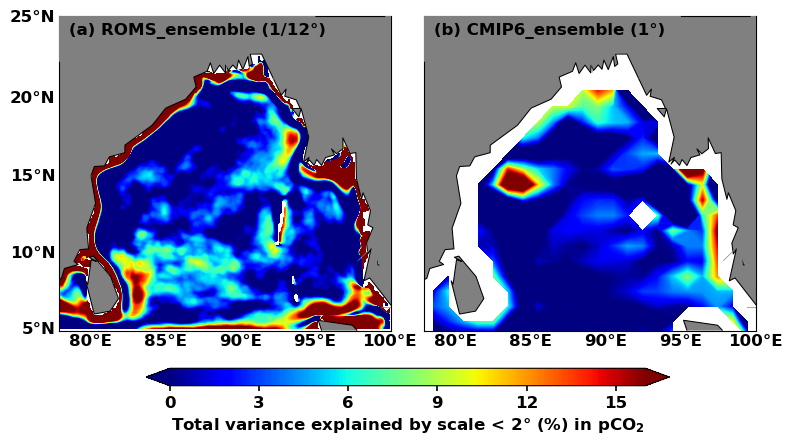

In [11]:
plt.rcParams['font.weight'] = 'bold'
from mpl_toolkits.basemap import Basemap

fig, ax = plt.subplots(1, 2, figsize=(9, 7))  ## Actual figsize=(20, 16) ##vertical four (18, 14)
plt.subplots_adjust(wspace=.1)


map = Basemap(projection='merc', resolution='c',
              llcrnrlat=4.9, urcrnrlat=25.1,
              llcrnrlon=77.9, urcrnrlon=100.1)

masked_lon, masked_lat = np.meshgrid(ROMS.LON_RHO, ROMS.LAT_RHO)
lon, lat = map(masked_lon, masked_lat)

masked_lon1, masked_lat1 = np.meshgrid(CMIP.LON_RHO, CMIP.LAT_RHO)
lon1, lat1 = map(masked_lon1, masked_lat1)


levels_diff1 = np.arange(0,16.1,0.1)


cmapp= 'jet'

p = plot_map(ax[0], map, (eddy_ROMS[4]*100/eddy_ROMS[2]), lon, lat, levels_diff1, cmap=cmapp, extend='both',show_lat=True,show_lon=True)
q = plot_map(ax[1], map, (eddy_CMIP[4]*100/eddy_CMIP[2]), lon1, lat1,levels_diff1, cmap=cmapp, extend='both',show_lat=False,show_lon=True)


cb1 = plt.colorbar(p, ax=[ax[0],ax[1]], orientation='horizontal',ticks=np.arange(0,16,3),shrink=0.75, pad=0.07, aspect=30, extend='max')
# ax[0].set_title('ROMS_ensemble (1/12°)', fontsize=15, fontweight='bold')
# ax[1].set_title('CMIP_ensemble (1°)', fontsize=15, fontweight='bold')
ax[0].text(
    0.03, 0.94,
    '(a) ROMS_ensemble (1/12°)',
    transform=ax[0].transAxes,
    fontsize=12,
    fontweight='bold',
    zorder=100
#     bbox=dict(facecolor='none', alpha=0.7, edgecolor='none',zorder=100)
)

ax[1].text(
    0.03, 0.94,
    '(b) CMIP6_ensemble (1°)',
    transform=ax[1].transAxes,
    fontsize=12,
    fontweight='bold',
    zorder=100
)

cb1.ax.tick_params(labelsize=12, width=1.2)
cb1.ax.set_xlabel('Total variance explained by scale < 2° (%) in pCO$_{\mathbf{2}}$', fontsize=12, fontweight='bold')

# plt.savefig('Mesoscale_Impact.png',dpi=600,facecolor='w', edgecolor='w',bbox_inches='tight')         